# Histogram

This section showcases the histogram. It contains examples of how to create histograms using the [datachart.charts.Histogram](../../../references/charts/#datachart.charts.Histogram) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-histogram), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the histograms are created using the `Histogram` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import Histogram

## Histogram Input Attributes

The `Histogram` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the values to bin. For a single histogram, `data` is a list of dictionaries. For multiple histograms, `data` is a list of lists.

```python
Histogram(
    data=[{                                             # A list of histogram data points (or list of lists for multiple charts)
        "x":    Union[int, float],                      # The value to bin
    }],
    style={                                             # The style of the histogram (optional)
        "plot_hist_color":         Optional[str],       # The color of the histogram (hex color code)
        "plot_hist_alpha":         Optional[float],     # The alpha of the histogram (how visible it is)
        "plot_hist_zorder":        Optional[int],       # The zorder of the histogram
        "plot_hist_fill":          Optional[bool],      # Whether the bars are filled
        "plot_hist_hatch":         Optional[HATCH_STYLE], # The hatch pattern of the bars
        "plot_hist_type":          Optional[HISTOGRAM_TYPE], # The histogram type (bar, step, etc.)
        "plot_hist_align":         Optional[str],       # The bar alignment within the bin ("left", "mid", "right")
        "plot_hist_edge_width":    Optional[float],     # The edge width of the bars
        "plot_hist_edge_color":    Optional[str],       # The edge color of the bars (hex color code)
        "plot_xticks_label_rotate": Optional[float],    # The x-axis tick label rotation
        "plot_yticks_label_rotate": Optional[float],    # The y-axis tick label rotation
    },
    subtitle=Optional[str],                             # The subtitle of the chart (or list for multiple charts)
    emphasis=Optional[str],                             # "highlight" or "background" (or list for multiple charts)
    title=Optional[str],                                # The title of the chart
    xlabel=Optional[str],                               # The x-axis label
    ylabel=Optional[str],                               # The y-axis label

    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    show_grid=Optional[str],                            # Which grid lines to show ("both", "x", "y")
    aspect_ratio=Optional[str],                         # The aspect ratio of the axes ("auto", "equal")
    show_legend=Optional[bool],                         # Whether to show the legend
    num_bins=Optional[int],                             # The number of bins (default: 20)
    orientation=Optional[str],                          # The orientation of the bars ("vertical", "horizontal")
    show_density=Optional[bool],                        # Whether to show the density instead of the count
    show_cumulative=Optional[bool],                     # Whether to show the cumulative distribution

    subplots=Optional[bool],                            # Whether to draw each chart in its own subplot
    max_cols=Optional[int],                             # Maximum number of subplots per row
    sharex=Optional[bool],                              # Whether subplots share the x-axis
    sharey=Optional[bool],                              # Whether subplots share the y-axis
    scalex=Optional[str],                               # The x-axis scale ("linear", "log", "symlog", "asinh")
    scaley=Optional[str],                               # The y-axis scale ("linear", "log", "symlog", "asinh")
    xmin=Optional[Union[int, float]],                   # The x-axis range
    xmax=Optional[Union[int, float]],
    ymin=Optional[Union[int, float]],                   # The y-axis range
    ymax=Optional[Union[int, float]],

    xticks=Optional[List[Union[int, float]]],           # the x-axis ticks
    xticklabels=Optional[List[str]],                    # the x-axis tick labels (must be same length as xticks)
    xtickrotate=Optional[int],                          # the x-axis tick labels rotation
    yticks=Optional[List[Union[int, float]]],           # the y-axis ticks
    yticklabels=Optional[List[str]],                    # the y-axis tick labels (must be same length as yticks)
    ytickrotate=Optional[int],                          # the y-axis tick labels rotation

    vlines=Optional[Union[dict, List[dict]]],           # the vertical lines
    hlines=Optional[Union[dict, List[dict]]],           # the horizontal lines

    x=Optional[str],                                    # the key holding the value to bin (default: "x")
)
```

For more details, see the [datachart.charts.Histogram](../../../references/charts/#datachart.charts.Histogram) function.

## Basics

The examples in this guide share one dataset: the flipper length (in millimeters) and body mass (in grams) of the 342 penguins of the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset, measured on three islands of the Palmer Archipelago, Antarctica, and released under CC0. The data is hard-coded in a hidden cell; `penguins` holds one point per penguin, and `penguins_by_species` holds one list per species — Adelie, Chinstrap and Gentoo — in the order of `SPECIES`.

In [2]:
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]

# (flipper length in mm, body mass in g) per penguin, by species
PENGUINS = {
    "Adelie": [
        (181, 3750), (186, 3800), (195, 3250), (193, 3450), (190, 3650), (181, 3625),
        (195, 4675), (193, 3475), (190, 4250), (186, 3300), (180, 3700), (182, 3200),
        (191, 3800), (198, 4400), (185, 3700), (195, 3450), (197, 4500), (184, 3325),
        (194, 4200), (174, 3400), (180, 3600), (189, 3800), (185, 3950), (180, 3800),
        (187, 3800), (183, 3550), (187, 3200), (172, 3150), (180, 3950), (178, 3250),
        (178, 3900), (188, 3300), (184, 3900), (195, 3325), (196, 4150), (190, 3950),
        (180, 3550), (181, 3300), (184, 4650), (182, 3150), (195, 3900), (186, 3100),
        (196, 4400), (185, 3000), (190, 4600), (182, 3425), (179, 2975), (190, 3450),
        (191, 4150), (186, 3500), (188, 4300), (190, 3450), (200, 4050), (187, 2900),
        (191, 3700), (186, 3550), (193, 3800), (181, 2850), (194, 3750), (185, 3150),
        (195, 4400), (185, 3600), (192, 4050), (184, 2850), (192, 3950), (195, 3350),
        (188, 4100), (190, 3050), (198, 4450), (190, 3600), (190, 3900), (196, 3550),
        (197, 4150), (190, 3700), (195, 4250), (191, 3700), (184, 3900), (187, 3550),
        (195, 4000), (189, 3200), (196, 4700), (187, 3800), (193, 4200), (191, 3350),
        (194, 3550), (190, 3800), (189, 3500), (189, 3950), (190, 3600), (202, 3550),
        (205, 4300), (185, 3400), (186, 4450), (187, 3300), (208, 4300), (190, 3700),
        (196, 4350), (178, 2900), (192, 4100), (192, 3725), (203, 4725), (183, 3075),
        (190, 4250), (193, 2925), (184, 3550), (199, 3750), (190, 3900), (181, 3175),
        (197, 4775), (198, 3825), (191, 4600), (193, 3200), (197, 4275), (191, 3900),
        (196, 4075), (188, 2900), (199, 3775), (189, 3350), (189, 3325), (187, 3150),
        (198, 3500), (176, 3450), (202, 3875), (186, 3050), (199, 4000), (191, 3275),
        (195, 4300), (191, 3050), (210, 4000), (190, 3325), (197, 3500), (193, 3500),
        (199, 4475), (187, 3425), (190, 3900), (191, 3175), (200, 3975), (185, 3400),
        (193, 4250), (193, 3400), (187, 3475), (188, 3050), (190, 3725), (192, 3000),
        (185, 3650), (190, 4250), (184, 3475), (195, 3450), (193, 3750), (187, 3700),
        (201, 4000),
    ],
    "Chinstrap": [
        (192, 3500), (196, 3900), (193, 3650), (188, 3525), (197, 3725), (198, 3950),
        (178, 3250), (197, 3750), (195, 4150), (198, 3700), (193, 3800), (194, 3775),
        (185, 3700), (201, 4050), (190, 3575), (201, 4050), (197, 3300), (181, 3700),
        (190, 3450), (195, 4400), (181, 3600), (191, 3400), (187, 2900), (193, 3800),
        (195, 3300), (197, 4150), (200, 3400), (200, 3800), (191, 3700), (205, 4550),
        (187, 3200), (201, 4300), (187, 3350), (203, 4100), (195, 3600), (199, 3900),
        (195, 3850), (210, 4800), (192, 2700), (205, 4500), (210, 3950), (187, 3650),
        (196, 3550), (196, 3500), (196, 3675), (201, 4450), (190, 3400), (212, 4300),
        (187, 3250), (198, 3675), (199, 3325), (201, 3950), (193, 3600), (203, 4050),
        (187, 3350), (197, 3450), (191, 3250), (203, 4050), (202, 3800), (194, 3525),
        (206, 3950), (189, 3650), (195, 3650), (207, 4000), (202, 3400), (193, 3775),
        (210, 4100), (198, 3775),
    ],
    "Gentoo": [
        (211, 4500), (230, 5700), (210, 4450), (218, 5700), (215, 5400), (210, 4550),
        (211, 4800), (219, 5200), (209, 4400), (215, 5150), (214, 4650), (216, 5550),
        (214, 4650), (213, 5850), (210, 4200), (217, 5850), (210, 4150), (221, 6300),
        (209, 4800), (222, 5350), (218, 5700), (215, 5000), (213, 4400), (215, 5050),
        (215, 5000), (215, 5100), (216, 4100), (215, 5650), (210, 4600), (220, 5550),
        (222, 5250), (209, 4700), (207, 5050), (230, 6050), (220, 5150), (220, 5400),
        (213, 4950), (219, 5250), (208, 4350), (208, 5350), (208, 3950), (225, 5700),
        (210, 4300), (216, 4750), (222, 5550), (217, 4900), (210, 4200), (225, 5400),
        (213, 5100), (215, 5300), (210, 4850), (220, 5300), (210, 4400), (225, 5000),
        (217, 4900), (220, 5050), (208, 4300), (220, 5000), (208, 4450), (224, 5550),
        (208, 4200), (221, 5300), (214, 4400), (231, 5650), (219, 4700), (230, 5700),
        (214, 4650), (229, 5800), (220, 4700), (223, 5550), (216, 4750), (221, 5000),
        (221, 5100), (217, 5200), (216, 4700), (230, 5800), (209, 4600), (220, 6000),
        (215, 4750), (223, 5950), (212, 4625), (221, 5450), (212, 4725), (224, 5350),
        (212, 4750), (228, 5600), (218, 4600), (218, 5300), (212, 4875), (230, 5550),
        (218, 4950), (228, 5400), (212, 4750), (224, 5650), (214, 4850), (226, 5200),
        (216, 4925), (222, 4875), (203, 4625), (225, 5250), (219, 4850), (228, 5600),
        (215, 4975), (228, 5500), (216, 4725), (215, 5500), (210, 4700), (219, 5500),
        (208, 4575), (209, 5500), (216, 5000), (229, 5950), (213, 4650), (230, 5500),
        (217, 4375), (230, 5850), (217, 4875), (222, 6000), (214, 4925), (215, 4850),
        (222, 5750), (212, 5200), (213, 5400),
    ],
}

penguins = [
    {"x": flipper, "species": species, "body_mass": mass}
    for species in SPECIES
    for flipper, mass in PENGUINS[species]
]
penguins_by_species = [
    [point for point in penguins if point["species"] == species]
    for species in SPECIES
]

Each data point is a dictionary with an `x` value — here the flipper length — which the histogram bins and counts. The other keys are carried along and ignored — the histogram reads `x` only:

In [3]:
penguins[:3]

[{'x': 181, 'species': 'Adelie', 'body_mass': 3750},
 {'x': 186, 'species': 'Adelie', 'body_mass': 3800},
 {'x': 195, 'species': 'Adelie', 'body_mass': 3250}]

**Basic example.** Only the `data` argument is required to draw the histogram.

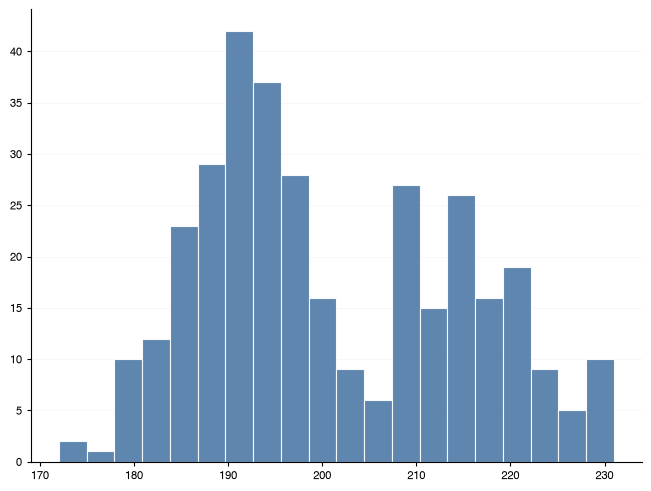

In [4]:
Histogram(
    # add the data to the chart
    data=penguins
).show()

## Customizing the Histogram

Every customization is either a keyword argument of `Histogram` or a `plot_hist_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                              | Use                                                                     | See |
| :-------------------------------------- | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels             | `title`, `xlabel`, `ylabel`                                             | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| set custom tick positions and labels    | `xticks`, `xticklabels`, `yticks`, `yticklabels`                        | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| rotate the tick labels                  | `xtickrotate`, `ytickrotate`                                            | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range                      | `xmin`, `xmax`, `ymin`, `ymax`                                          | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                       | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show grid lines                         | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| change how finely the values are binned | `num_bins`                                                              | [Number of bins](#number-of-bins) |
| change the bar color or transparency    | `style={"plot_hist_color": ..., "plot_hist_alpha": ...}`               | [Histogram style](#histogram-style) |
| draw the histogram as a step outline    | `style={"plot_hist_type": ...}`                                         | [Histogram style](#histogram-style) |
| hatch or outline the bars               | `style={"plot_hist_hatch": ..., "plot_hist_edge_width": ..., "plot_hist_edge_color": ...}` | [Histogram style](#histogram-style) |
| draw the bars horizontally              | `orientation`                                                           | [Orientation](#orientation) |
| highlight one series, mute the rest     | `emphasis`                                                              | [Emphasis](#emphasis) |
| mark a threshold or a reference value   | `vlines`, `hlines`                                                      | [Reference lines](#reference-lines) |
| compare several series in one chart     | `data` as a list of lists, `subtitle`, `show_legend`                    | [Multiple Histograms](#multiple-histograms) |
| stack or overlay the series             | `bar_mode`                                                              | [Multiple Histograms](#multiple-histograms) |
| draw each series in its own subplot     | `subplots`, `sharex`, `sharey`, `max_cols`                              | [Subplots](#subplots) |
| show densities or cumulative counts     | `show_density`, `show_cumulative`                                       | [Histogram Views](#histogram-views) |
| overlay a smooth density curve          | `stats.kde1d`, `Panel`                                                  | [Density curve](#density-curve) |
| use a logarithmic axis                  | `scalex`, `scaley`                                                      | [Axis scales](#axis-scales) |
| plot data with other key names          | `x`                                                                     | [Custom data keys](#custom-data-keys) |
| save the chart to a file                | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.HistStyleAttrs](../../../references/typings/#datachart.typings.HistStyleAttrs) type; the full list of parameters is in the [datachart.charts.Histogram](../../../references/charts/#datachart.charts.Histogram) reference.

### Title, axis labels and ticks

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes. The tick positions and their labels can be set with `xticks` and `xticklabels` (or `yticks` and `yticklabels`) — here the flipper length is ticked every 10 mm. Tick labels can be rotated with `xtickrotate` (or `ytickrotate`), and the axis range can be fixed with `xmin`, `xmax`, `ymin` and `ymax`.

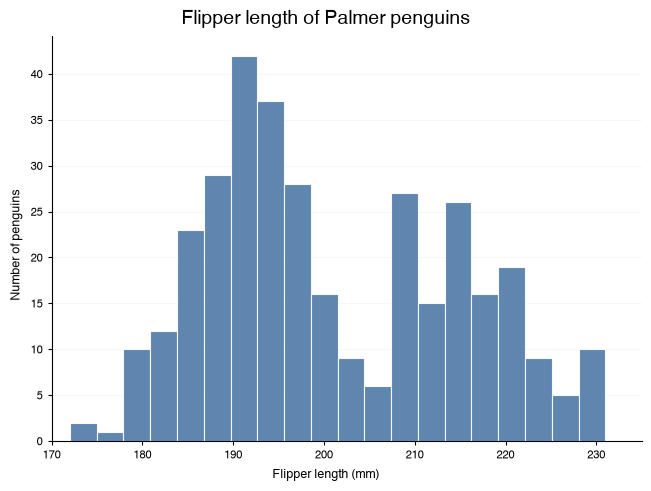

In [5]:
FLIPPER_TICKS = [170, 180, 190, 200, 210, 220, 230]

Histogram(
    data=penguins,
    # add the title
    title="Flipper length of Palmer penguins",
    # add the x and y axis labels
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    # tick the flipper length every 10 mm
    xticks=FLIPPER_TICKS,
    # fix the x-axis range
    xmin=170,
    xmax=235,
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains some of the predefined figure sizes.

To add the grid, add the `show_grid` attribute. The possible options are:

| Option | Description |
| --- | --- |
| `"both"` | shows both the x-axis and the y-axis gridlines. |
| `"x"` | shows only the x-axis grid lines. |
| `"y"` | shows only the y-axis grid lines. |

Again, `datachart` provides a [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant, which contains the supported options. For a vertical histogram the counts are read off the y-axis, so `"y"` is usually all the grid a histogram needs.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

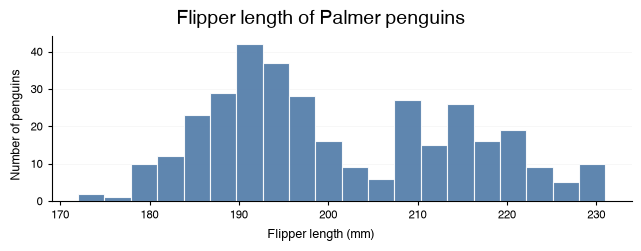

In [7]:
Histogram(
    data=penguins,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # add to show the grid lines
    show_grid=SHOW_GRID.Y,
).show()

### Number of bins

The histogram splits the range of the values into equal-width bins and counts the values in each. By default there are 20 bins; the `num_bins` attribute changes that. Fewer bins smooth the distribution, more bins expose its detail — and its noise. The flipper lengths run from 172 to 231 mm: with 8 bins the distribution is reduced to a coarse silhouette, with 40 bins every bin is about 1.5 mm wide and the two peaks — the Adelie and Chinstrap penguins around 190 mm, the Gentoo penguins around 215 mm — stand apart, at the price of jagged bars.

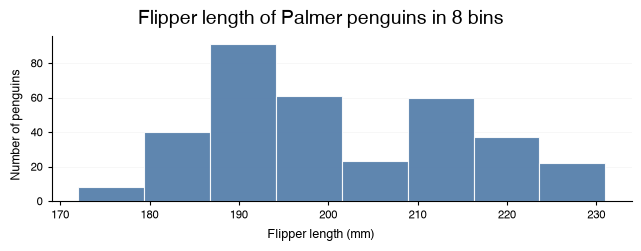

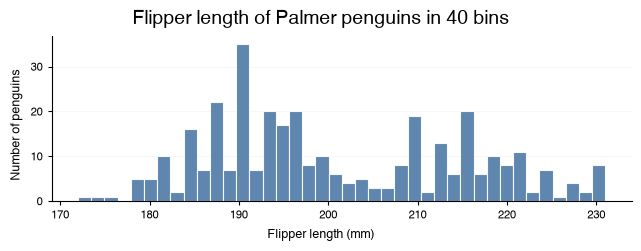

In [8]:
for num_bins in [8, 40]:
    Histogram(
        data=penguins,
        title=f"Flipper length of Palmer penguins in {num_bins} bins",
        xlabel="Flipper length (mm)",
        ylabel="Number of penguins",
        xticks=FLIPPER_TICKS,
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
        # change the number of bins
        num_bins=num_bins,
    ).show()

### Histogram style

To change the histogram style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.HistStyleAttrs](../../../references/typings/#datachart.typings.HistStyleAttrs) type, which contains the following attributes:

| Attribute                     | Description |
| :---------------------------- | :---------- |
| `"plot_hist_color"`           | The color of the histogram (hex color code).              |
| `"plot_hist_alpha"`           | The alpha of the histogram (how visible it is).           |
| `"plot_hist_zorder"`          | The zorder of the histogram.                              |
| `"plot_hist_fill"`            | Whether the bars are filled.                              |
| `"plot_hist_hatch"`           | The hatch pattern of the bars.                            |
| `"plot_hist_type"`            | The histogram type (bar, step, etc.).                     |
| `"plot_hist_align"`           | The bar alignment within the bin (`"left"`, `"mid"`, `"right"`). |
| `"plot_hist_edge_width"`      | The edge width of the bars.                               |
| `"plot_hist_edge_color"`      | The edge color of the bars (hex color code).              |
| `"plot_xticks_label_rotate"`  | The rotation of the x-axis tick labels.                   |
| `"plot_yticks_label_rotate"`  | The rotation of the y-axis tick labels.                   |

Again, to help with the style settings, the [datachart.constants](../../../references/constants/) module contains the following constants:

| Constant | Description |
| :------- | :---------- |
| [datachart.constants.HATCH_STYLE](../../../references/constants/#datachart.constants.HATCH_STYLE) | The hatch pattern of the bars. |
| [datachart.constants.HISTOGRAM_TYPE](../../../references/constants/#datachart.constants.HISTOGRAM_TYPE) | The histogram type. |

The histogram type decides how the bins are drawn:

| Type            | Description |
| :-------------- | :---------- |
| `"bar"`         | One bar per bin (the default). |
| `"step"`        | An unfilled outline that steps from bin to bin. |
| `"stepfilled"`  | A filled outline that steps from bin to bin. |

The type is a per-series render style; how several series share the axis is the `bar_mode` argument's job (see [Multiple Histograms](#multiple-histograms)). For `"step"` the outline is the mark itself, so it draws in the series color at the theme's line width; `plot_hist_edge_color` and `plot_hist_edge_width` override that explicitly.

The example below changes the color, transparency, hatch, outline and type of the histogram in one go. Any attribute you leave out keeps the value of the active theme.

In [9]:
from datachart.constants import HATCH_STYLE, HISTOGRAM_TYPE

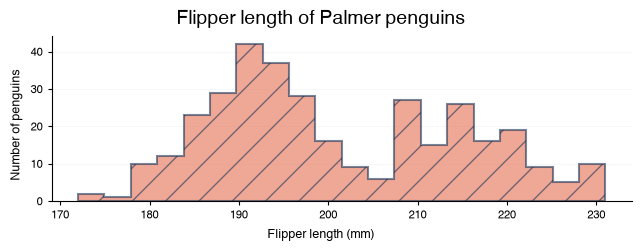

In [10]:
Histogram(
    data=penguins,
    # define the style of the histogram
    style={
        "plot_hist_color": "#e76f51",
        "plot_hist_alpha": 0.6,
        "plot_hist_hatch": HATCH_STYLE.DIAGONAL,
        "plot_hist_edge_width": 1.5,
        "plot_hist_edge_color": "#1d3557",
        "plot_hist_type": HISTOGRAM_TYPE.STEP_FILLED,
    },
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Orientation

To draw the bars horizontally, add the `orientation` attribute, which supports the following values:

| Value          | Description |
| :------------- | :---------- |
| `"vertical"`   | The bars rise from the x-axis (the default). |
| `"horizontal"` | The bars extend from the y-axis. |

Again, to help with the settings, the [datachart.constants](../../../references/constants/) module contains the [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant. With horizontal bars the binned values sit on the y-axis and the counts on the x-axis, so the axis labels, the ticks and the grid swap places too.

In [11]:
from datachart.constants import ORIENTATION

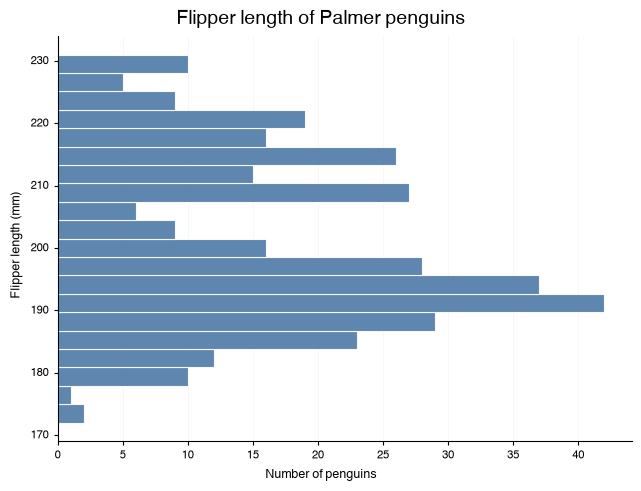

In [12]:
Histogram(
    data=penguins,
    title="Flipper length of Palmer penguins",
    # the flipper length is now on the y-axis
    xlabel="Number of penguins",
    ylabel="Flipper length (mm)",
    yticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    # change the grid to match the change in orientation
    show_grid=SHOW_GRID.X,
    # change the orientation of the bars
    orientation=ORIENTATION.HORIZONTAL,
).show()

### Emphasis

When a chart carries several series, the story is often about one of them. The `emphasis` attribute expresses that directly: `"highlight"` thickens the outline of a series and brings it to the front, `"background"` mutes a series (the theme's muted color at a lower alpha, drawn behind the others), and `None` leaves a series unchanged. For multiple charts, `emphasis` is a list aligned with `data`, just like `subtitle` and `style`. Only emphasized-or-unset series appear in the legend — background series drop out of it. The role strings are also available as the [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants.

Emphasis also changes how the histograms are drawn: when any series carries an emphasis role, the histograms draw individually, overlaid on shared bins, instead of stacked on top of each other — a muted background stacked under the highlight would make no sense.

The example highlights the Gentoo penguins against the other two species. See the [Highlighting](../../styling/highlighting/) guide for how emphasis works across all chart types and themes.

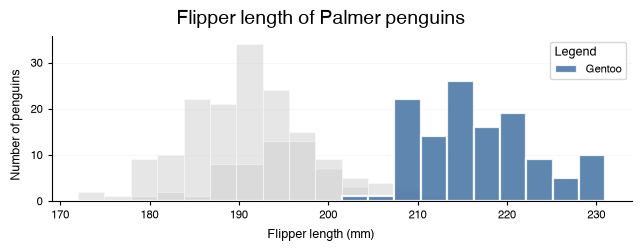

In [13]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    # mute the Adelie and Chinstrap penguins, highlight the Gentoo penguins
    emphasis=["background", "background", "highlight"],
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Reference lines

Reference lines mark a threshold or a reference value on the chart.

**Vertical lines.** Use the `vlines` argument with the [datachart.typings.VLinePlotAttrs](../../../references/typings/#datachart.typings.VLinePlotAttrs) typing, which is either a `dict` or a `List[dict]` where each dictionary contains some of the following attributes:

```python
{
  "x":    Union[int, float],                 # The x-axis value
  "ymin": Optional[Union[int, float]],       # The minimum y-axis value
  "ymax": Optional[Union[int, float]],       # The maximum y-axis value
  "style": {                                 # The style of the line (optional)
    "plot_vline_color": Optional[str],       # The color of the line (hex color code)
    "plot_vline_style": Optional[LineStyle], # The line style (solid, dashed, etc.)
    "plot_vline_width": Optional[float],     # The width of the line
    "plot_vline_alpha": Optional[float],     # The alpha of the line (how visible the line is)
  },
  "label": Optional[str],                    # The label of the line (shown in the legend)
}
```

**Horizontal lines.** Use the `hlines` argument with the [datachart.typings.HLinePlotAttrs](../../../references/typings/#datachart.typings.HLinePlotAttrs) typing, which has the same shape with `y`, `xmin`, `xmax` and `plot_hline_*` style attributes.

On a histogram a vertical line marks a value on the binned axis — a mean, a cut-off, a specification limit — while a horizontal line marks a count. The example marks the mean (201 mm) and the median (197 mm) of the flipper lengths; the gap between the two is the mark of the long-flippered Gentoo penguins pulling the mean to the right. The line labels appear in the legend.

In [14]:
from datachart.constants import LINE_STYLE

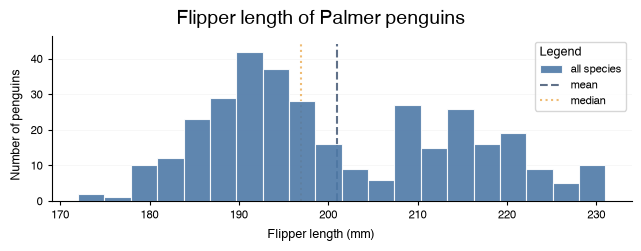

In [15]:
Histogram(
    data=penguins,
    # name the series for the legend
    subtitle="all species",
    # add vertical lines at the mean and the median flipper length
    vlines=[
        {
            "x": 201,
            "label": "mean",
            "style": {
                "plot_vline_color": "#1d3557",
                "plot_vline_style": LINE_STYLE.DASHED,
                "plot_vline_width": 1.5,
            },
        },
        {
            "x": 197,
            "label": "median",
            "style": {
                "plot_vline_color": "#e9a03b",
                "plot_vline_style": LINE_STYLE.DOTTED,
                "plot_vline_width": 1.5,
            },
        },
    ],
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

## Multiple Histograms

To create multiple histograms, pass a list of lists to the `data` argument. Each inner list represents the data for one histogram. Per-chart attributes like `subtitle`, `style` and `emphasis` can be passed as lists, where each element corresponds to a chart.

<div class="admonition note">
    <p class="admonition-title">Multiple charts pattern</p>
    <p style="margin-top: .6rem; margin-bottom: .6rem">
        For multiple charts, <code>data</code> becomes a list of lists, and per-chart attributes like <code>subtitle</code> and <code>style</code> become lists where each element applies to the corresponding chart.
    </p>
</div>

The `penguins_by_species` dataset is such a list of lists, one series per species. By default, multiple histograms in one chart are binned on shared bins and **stacked** on top of each other, so the outline of the stack is the histogram of all the values together and each color shows a species' share of every bin. Pass `bar_mode="overlay"` to draw the series individually over each other instead. Separate series can also be styled separately: a single `style` dictionary applies to every chart, while a list of dictionaries styles each chart on its own (`None` keeps the theme style for that chart).

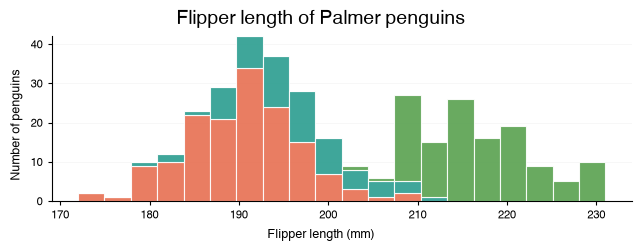

In [16]:
Histogram(
    # use a list of lists to define multiple histograms
    data=penguins_by_species,
    # style can be a list (one per chart) or a single dict (applies to all)
    style=[
        {"plot_hist_color": "#e76f51"},
        {"plot_hist_color": "#2a9d8f"},
        None,  # keep the theme style for the third chart
    ],
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Sub-chart subtitles

We can name each chart by passing a list of subtitles to the `subtitle` argument. In addition, to help with discerning which chart is which, use the `show_legend` argument to show the legend of the charts.

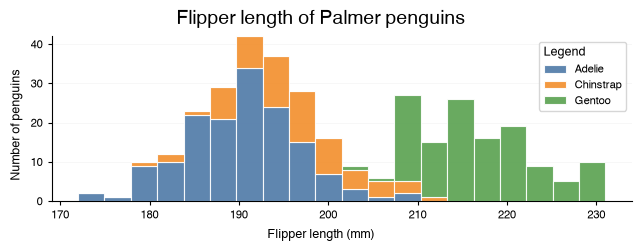

In [17]:
Histogram(
    data=penguins_by_species,
    # add a subtitle to each chart
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # show the legend
    show_legend=True,
).show()

### Subplots

To draw each chart in its own subplot, add the `subplots` attribute. The chart's `subtitle` are then added at the top of each subplot, while the `title`, `xlabel` and `ylabel` are positioned to be global for all charts. The `max_cols` attribute limits the number of subplots per row. Each subplot bins its own values and scales its own axes, so the three histograms are not yet comparable — the next section fixes that.

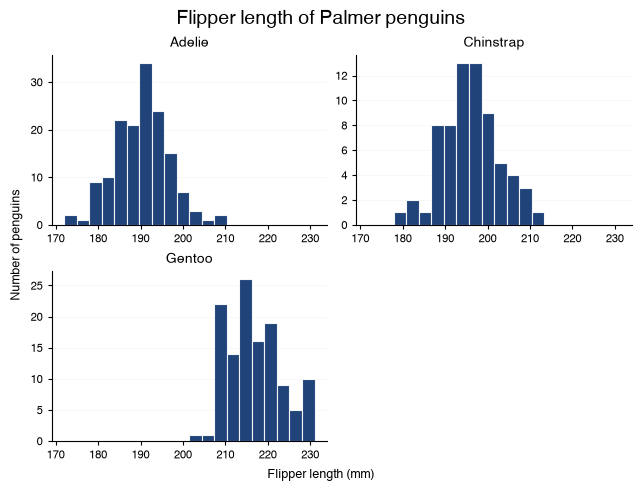

In [18]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    # show each chart in its own subplot
    subplots=True,
    # at most two subplots per row
    max_cols=2,
).show()

### Sharing the x-axis and/or y-axis across subplots

To share the x-axis and/or y-axis across subplots, add the `sharex` and/or `sharey` attributes, which are boolean values that specify whether to share the axis across all subplots. With a shared x-axis the subplots also share their bins, so the species line up bin for bin; with a shared y-axis the bar heights become comparable and the smaller Chinstrap sample (68 penguins against 151 Adelie) no longer fills its subplot.

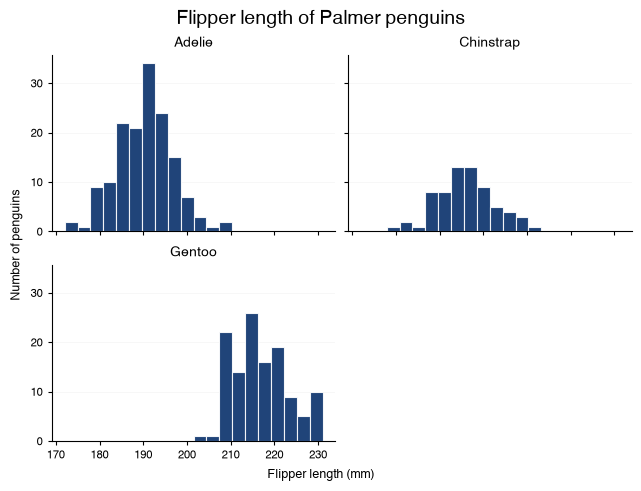

In [19]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    subplots=True,
    max_cols=2,
    # share the x-axis across subplots
    sharex=True,
    # share the y-axis across subplots
    sharey=True,
).show()

## Histogram Views

A histogram counts values per bin by default. Two attributes change what the bars measure: `show_density` turns the counts into a probability density, and `show_cumulative` accumulates the bins from left to right. They apply to every chart in the figure, and they combine.

### Density distribution view

To show the histograms as a density distribution, add the `show_density` attribute. The bars are scaled so that their total area is 1 — the bar heights are densities rather than counts, and the y-axis no longer depends on the sample size. That is what makes samples of different sizes comparable: per count, the 151 Adelie penguins tower over the 68 Chinstrap penguins; per density, the two species have distributions of about the same width, just shifted.

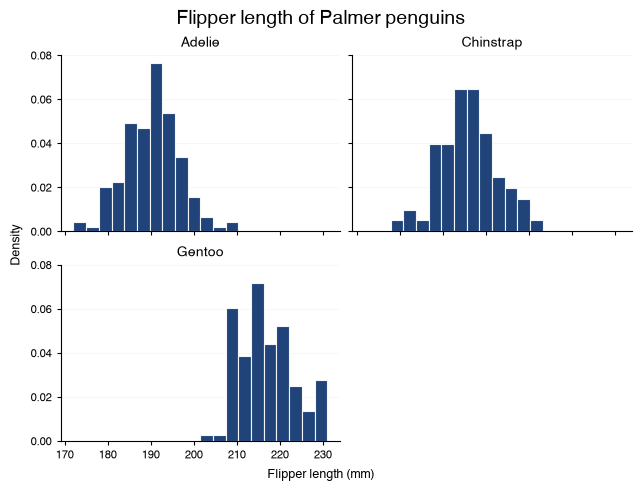

In [20]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Density",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    subplots=True,
    max_cols=2,
    sharex=True,
    sharey=True,
    # show the density instead of the count
    show_density=True,
).show()

### Density curve

A density histogram depends on where its bins fall; a kernel density estimate smooths the same values into a curve that does not. [datachart.utils.stats.kde1d](../../../references/utils/stats/#datachart.utils.stats.kde1d) computes it and returns the `{x, y}` points a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) draws, so there is no separate density chart: overlay the curve on the density histogram with [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel). Both integrate to 1, so they share the y-axis — pin the curve to it with `"y_axis": "left"`, or `Panel` moves it to a secondary axis when the two peaks differ. The `bandwidth` sets how smooth the curve is — a [datachart.constants.BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) rule (Scott's by default) or a scalar factor, where smaller values follow the values more closely — and `show_area` fills the curve, the way a density plot is usually drawn.

In [21]:
from datachart.charts import LineChart
from datachart.utils import Panel
from datachart.utils.stats import kde1d

/Users/eriknovak/Documents/Code/datachart/.claude/worktrees/kde-contour/datachart/utils/_internal/layers.py:2917: UserWarning: Charts at indices 0 and 1 are both on the left axis but have incompatible scales. Consider using explicit y_axis assignment or Grid.
  warnings.warn(


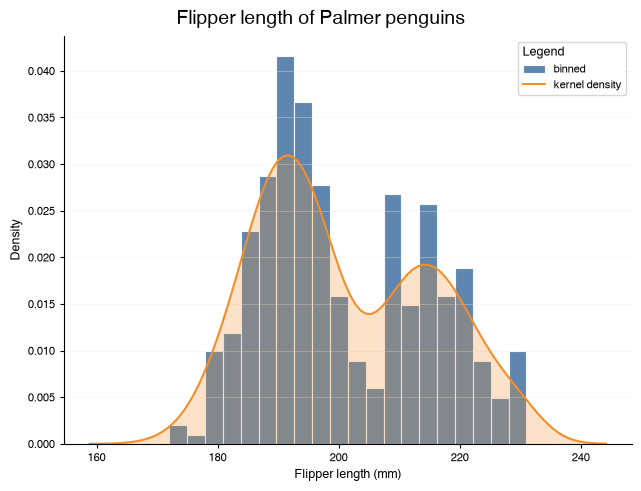

In [22]:
Panel(
    [
        Histogram(data=penguins, subtitle="binned", show_density=True),
        # the same values, smoothed into a curve
        {
            "figure": LineChart(
                data=kde1d([point["x"] for point in penguins]),
                subtitle="kernel density",
                show_area=True,
            ),
            # both are densities: keep the curve on the histogram's axis
            "y_axis": "left",
        },
    ],
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel_left="Density",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Cumulative distribution view

To show the histograms as a cumulative distribution, add the `show_cumulative` attribute. Each bar then holds the count of all the values up to and including its bin, so the bars climb from left to right and the last bar reaches the sample size. The cumulative view answers "how many penguins have flippers shorter than *x*?" directly — at the 200 mm mark nearly every Adelie penguin is already counted, seven in ten Chinstrap penguins, and not a single Gentoo penguin.

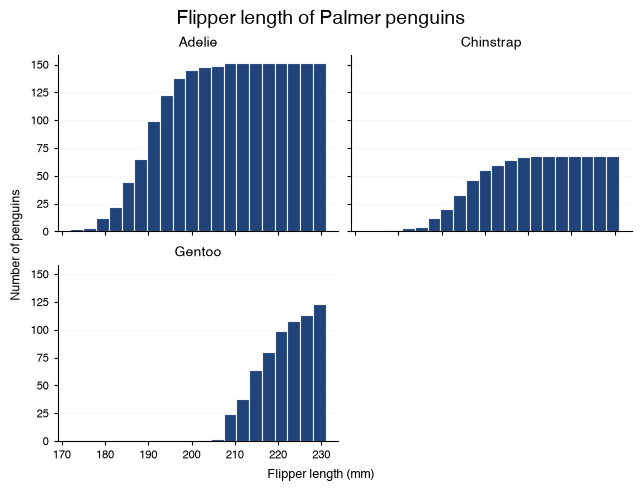

In [23]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    subplots=True,
    max_cols=2,
    sharex=True,
    sharey=True,
    # show the cumulative count
    show_cumulative=True,
).show()

### Cumulative & density distribution view

The `show_density` and `show_cumulative` attributes combine into the empirical cumulative distribution: every bar holds the share of the values up to its bin, the last bar reaches 1, and the species become comparable regardless of how many penguins were measured: four out of five Gentoo penguins have flippers longer than any Adelie penguin.

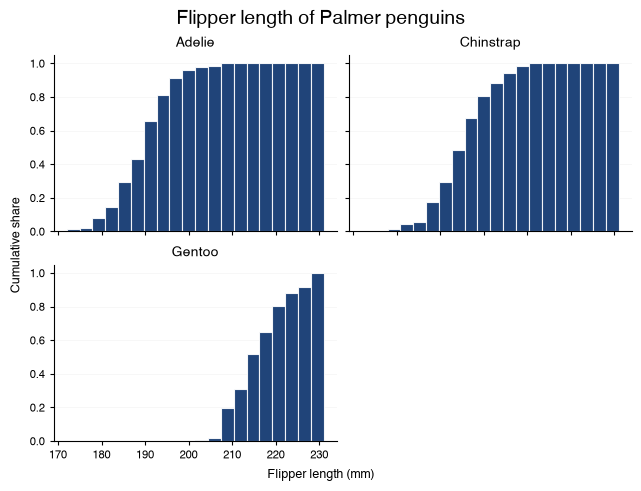

In [24]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Cumulative share",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    subplots=True,
    max_cols=2,
    sharex=True,
    sharey=True,
    # show the cumulative density
    show_density=True,
    show_cumulative=True,
).show()

## Additional Features

### Axis scales

The user can change the axis scale using the `scalex` and `scaley` attributes. The supported scale options are:

| Options      | Description |
| :----------- | :---------- |
| `"linear"`   | The linear scale.              |
| `"log"`      | The log scale.                 |
| `"symlog"`   | The symmetric log scale.       |
| `"asinh"`    | The asinh scale.               |

Again, to help with the options settings, the [datachart.constants](../../../references/constants/) module contains the following constants:

| Constant        | Description |
| :-------------- | :---------- |
| [datachart.constants.SCALE](../../../references/constants/#datachart.constants.SCALE) | The axis options. |

On a histogram the scale of the count axis is the one that usually matters. Bins in the tails of a distribution hold a handful of values and are barely visible next to the peak on a linear scale; a logarithmic y-axis gives every occupied bin a visible bar and shows how quickly the tails fall off. Note that the bins themselves stay equal-width on the data scale whichever axis scale is applied.

In [25]:
from datachart.constants import SCALE

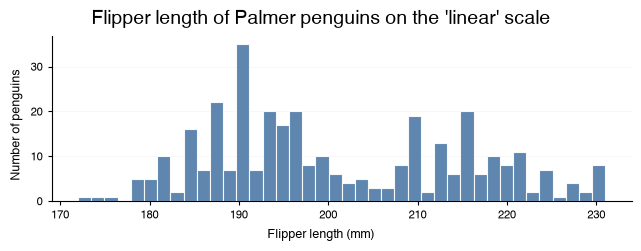

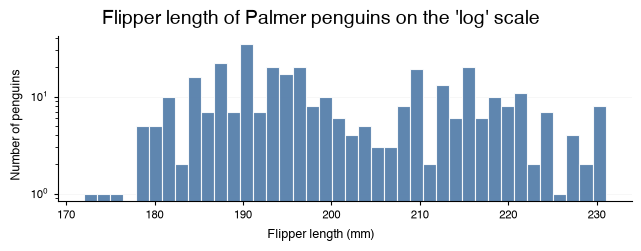

In [26]:
for scale in [SCALE.LINEAR, SCALE.LOG]:
    Histogram(
        data=penguins,
        title=f"Flipper length of Palmer penguins on the '{scale}' scale",
        xlabel="Flipper length (mm)",
        ylabel="Number of penguins",
        xticks=FLIPPER_TICKS,
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
        num_bins=40,
        # set the scale of the y axis
        scaley=scale,
    ).show()

### Custom data keys

By default, the `data` items are dictionaries with the key `x` holding the value to bin. Data that comes from elsewhere rarely calls its columns `x`, and renaming every key just to plot it is a chore. Instead, tell `Histogram` which key to read with the `x` argument. The `penguin_records` list below stores the same penguins under their natural names, and the example bins their body mass instead of their flipper length.

In [27]:
penguin_records = [
    {
        "species": species,
        "flipper_length_mm": flipper,
        "body_mass_g": mass,
    }
    for species in SPECIES
    for flipper, mass in PENGUINS[species]
]
penguin_records[:3]

[{'species': 'Adelie', 'flipper_length_mm': 181, 'body_mass_g': 3750},
 {'species': 'Adelie', 'flipper_length_mm': 186, 'body_mass_g': 3800},
 {'species': 'Adelie', 'flipper_length_mm': 195, 'body_mass_g': 3250}]

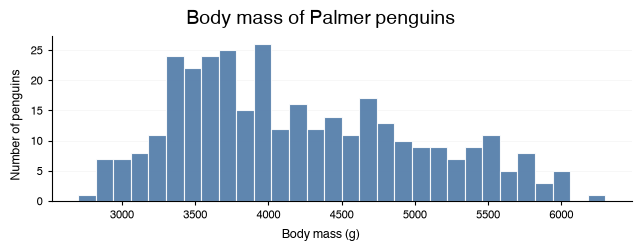

In [28]:
figure = Histogram(
    data=penguin_records,
    # specify which key holds the value to bin
    x="body_mass_g",
    title="Body mass of Palmer penguins",
    xlabel="Body mass (g)",
    ylabel="Number of penguins",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=30,
)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [29]:
from datachart.utils import save_figure

In [30]:
save_figure(figure, "./fig_histogram.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on real or realistic data. Each one states what its data is and where it comes from; the data itself lives in a hidden cell.

### Example 1: Marathon Finish Times (Bimodal Shape and Reference Lines)

`finish_times` holds the finish times, in minutes, of 3,000 illustrative marathon runners drawn from a seeded generator: a faster group of club runners finishing around 3:35 and a larger recreational group around 4:30, so the distribution has two peaks. The finish time is the kind of value people think of in round numbers, so `xticks` label the axis in hours and `vlines` mark the 3, 4 and 5 hour milestones most runners set themselves. Sixty bins make each bin about four minutes wide.

In [31]:
import numpy as np

rng = np.random.RandomState(26)
# finish times in minutes: club runners around 3:35, recreational runners around 4:30
club = rng.normal(215, 18, 1_000)
recreational = rng.normal(270, 28, 2_000)
finish_times = [{"x": float(minutes)} for minutes in np.concatenate([club, recreational])]

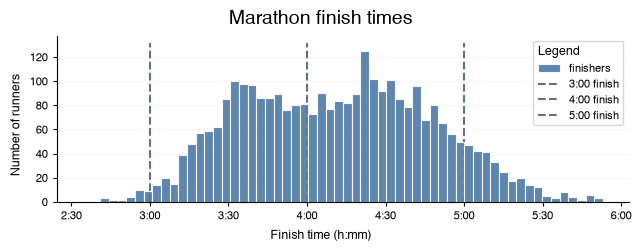

In [32]:
HOUR_TICKS = [150, 180, 210, 240, 270, 300, 330, 360]
HOUR_TICK_LABELS = ["2:30", "3:00", "3:30", "4:00", "4:30", "5:00", "5:30", "6:00"]

Histogram(
    data=finish_times,
    subtitle="finishers",
    # mark the round-hour milestones
    vlines=[
        {
            "x": minutes,
            "label": f"{minutes // 60}:00 finish",
            "style": {
                "plot_vline_color": "#1d3557",
                "plot_vline_style": LINE_STYLE.DASHED,
                "plot_vline_width": 1.5,
            },
        }
        for minutes in [180, 240, 300]
    ],
    title="Marathon finish times",
    xlabel="Finish time (h:mm)",
    ylabel="Number of runners",
    # label the ticks in hours
    xticks=HOUR_TICKS,
    xticklabels=HOUR_TICK_LABELS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=60,
    show_legend=True,
).show()

### Example 2: Session Duration of an A/B Test (Emphasis and Density View)

`session_durations` holds two series of illustrative session durations, in minutes, from an A/B test of a redesigned onboarding flow: 5,000 sessions of the control group and the 600 sessions of the much smaller variant group, both drawn from seeded log-normal generators. The question is whether the variant moved the distribution, so `emphasis` mutes the control group into a background reference and highlights the variant. With the roles set, the two histograms are overlaid on shared bins rather than stacked; `show_density` puts the samples on the same footing despite their very different sizes. The muted series drops out of the legend automatically.

In [33]:
import numpy as np

rng = np.random.RandomState(11)
# session durations in minutes: the variant sessions run about a third longer
control = rng.lognormal(mean=1.6, sigma=0.5, size=5_000)
variant = rng.lognormal(mean=1.9, sigma=0.5, size=600)
session_durations = [
    [{"x": float(minutes)} for minutes in control],
    [{"x": float(minutes)} for minutes in variant],
]

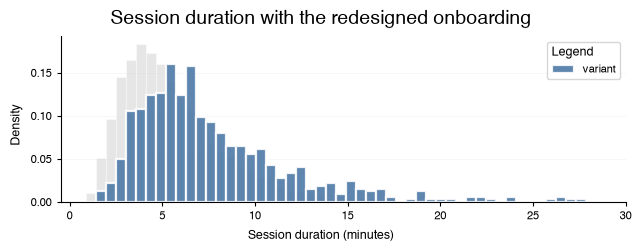

In [34]:
Histogram(
    data=session_durations,
    subtitle=["control", "variant"],
    # mute the control group, highlight the variant
    emphasis=["background", "highlight"],
    title="Session duration with the redesigned onboarding",
    xlabel="Session duration (minutes)",
    ylabel="Density",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=50,
    xmax=30,
    # compare the shapes, not the sample sizes
    show_density=True,
    show_legend=True,
).show()

### Example 3: Request Latency (Log Scale and Density View)

`latencies` holds the response time, in milliseconds, of 20,000 illustrative requests to a web service drawn from a seeded log-normal generator — the typical request answers in about 40 ms, but a long tail of slow requests stretches out to several hundred milliseconds. On a linear count axis the tail is invisible next to the peak, so `scaley` switches the y-axis to a log scale and every occupied bin gets a visible bar. `show_density` makes the y-axis independent of how many requests were sampled, and `vlines` mark the 200 ms latency objective that the tail has to stay under.

In [35]:
import numpy as np

rng = np.random.RandomState(5)
# response times in ms: a 40 ms median with a heavy tail
latencies = [{"x": float(ms)} for ms in rng.lognormal(mean=3.7, sigma=0.55, size=20_000)]

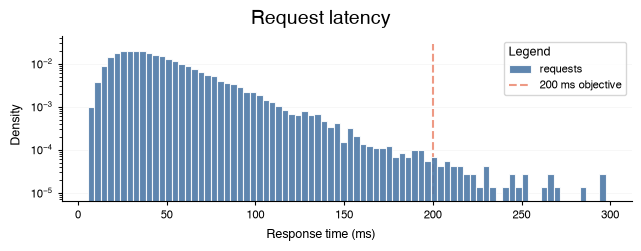

In [36]:
Histogram(
    data=latencies,
    subtitle="requests",
    # mark the latency objective
    vlines={
        "x": 200,
        "label": "200 ms objective",
        "style": {
            "plot_vline_color": "#e76f51",
            "plot_vline_style": LINE_STYLE.DASHED,
            "plot_vline_width": 1.5,
        },
    },
    title="Request latency",
    xlabel="Response time (ms)",
    ylabel="Density",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=80,
    # show the tail on a logarithmic density axis
    show_density=True,
    scaley=SCALE.LOG,
    show_legend=True,
).show()

### Example 4: Daily Rainfall at Four Stations (Subplots, Shared Axes and Custom Data Keys)

`rainfall_by_station` holds one series per weather station: the rainfall, in millimeters, on each of the wet days of one illustrative year at four stations of differing climates — a dry station with frequent light showers up to a wet station with occasional downpours — drawn from seeded gamma generators. The readings are stored under `rainfall_mm`, so the key is mapped with the `x` argument; `subplots` gives each station its own panel and `sharex` and `sharey` put the panels on the same bins and the same count axis, so a bar in one panel means the same as a bar in another.

In [37]:
import numpy as np

rng = np.random.RandomState(17)
# (number of wet days, mean rainfall in mm on a wet day) per station
STATIONS = {
    "Ridge": (210, 4.0),
    "Valley": (160, 6.0),
    "Coast": (140, 9.0),
    "Lakeside": (120, 14.0),
}
rainfall_by_station = [
    [
        {"station": station, "rainfall_mm": float(mm)}
        for mm in rng.gamma(shape=1.5, scale=mean / 1.5, size=wet_days)
    ]
    for station, (wet_days, mean) in STATIONS.items()
]

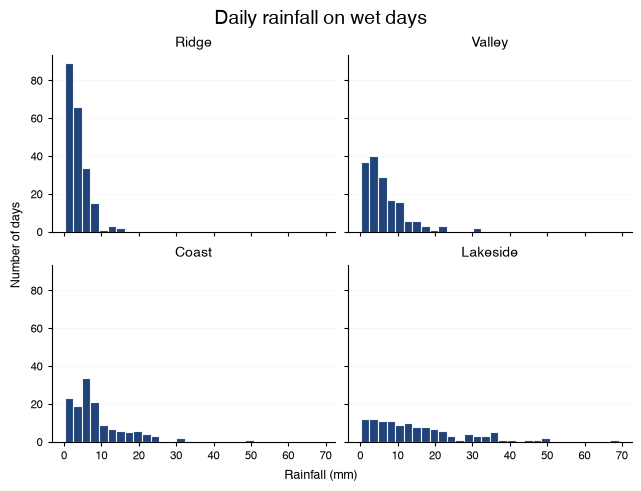

In [38]:
Histogram(
    data=rainfall_by_station,
    # the readings are stored as "rainfall_mm"
    x="rainfall_mm",
    subtitle=list(STATIONS),
    title="Daily rainfall on wet days",
    xlabel="Rainfall (mm)",
    ylabel="Number of days",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    num_bins=30,
    # one panel per station, on the same bins and count axis
    subplots=True,
    max_cols=2,
    sharex=True,
    sharey=True,
).show()